In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [3]:
path = '/content/drive/MyDrive/Merged_1.csv'

In [4]:
data = pd.read_csv(path)

In [5]:
data.shape

(21996, 22)

In [6]:
data = data.drop(['country_region', 'date.1'], axis=1)
data = data.rename(columns={
    'location.1': 'Country',
    'total_deaths': 'daily Deaths',
    'date': 'Date',
    'individualism': 'Individualism',
    'masculinity': 'Masculinity',
    'powerdistance': 'Power Distance',
    'uncertaintyavoidance': 'Uncertainty Avoidance',
    'longtermorientation': 'Long Term Orientation',
    'democracyindex2021': 'Democracy Index',
    'indulgence': 'Indulgence',
    'gdp_per_capita': 'GDP (per capita)',
    'aged_65_older': 'Aged 65 Older',
    'stringency_index': 'Stringency Index',
    'population': 'Population',
    'retail_and_recreation_percent_change_from_baseline': 'Retail and Recreation',
    'grocery_and_pharmacy_percent_change_from_baseline': 'Grocery and Pharmacy',
    'parks_percent_change_from_baseline': 'Parks',
    'transit_stations_percent_change_from_baseline': 'Transit Stations',
    'workplaces_percent_change_from_baseline': 'Workplaces',
    'residential_percent_change_from_baseline': 'Residential'
})
df = data
df.head()

,Country,daily Deaths,Date,Individualism,Masculinity,Power Distance,Indulgence,Uncertainty Avoidance,Long Term Orientation,Democracy Index,GDP (per capita),Aged 65 Older,Stringency Index,Population,Retail and Recreation,Grocery and Pharmacy,Parks,Transit Stations,Workplaces,Residential
0,Angola,NaN,25/03/2020,18,20,83,83,60,15,3,5819,2,33,33933611,-22.0,1.0,-24.0,-41.0,-22.0,15.0
1,Angola,NaN,26/03/2020,18,20,83,83,60,15,3,5819,2,33,33933611,-10.0,23.0,-9.0,-25.0,-27.0,11.0
2,Angola,NaN,27/03/2020,18,20,83,83,60,15,3,5819,2,91,33933611,-48.0,-22.0,-32.0,-52.0,-47.0,26.0
3,Angola,NaN,28/03/2020,18,20,83,83,60,15,3,5819,2,91,33933611,-51.0,-33.0,-28.0,-41.0,-22.0,20.0
4,Angola,2.0,29/03/2020,18,20,83,83,60,15,3,5819,2,91,33933611,-61.0,-40.0,-39.0,-57.0,-11.0,22.0


In [7]:

                                                                                                                          # Ensure your DataFrame is loaded as df
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values(['Country', 'Date'], inplace=True)
df['time_step'] = df.groupby('Country').cumcount()

                                                                                                                        # Encode countries
country_encoder = LabelEncoder()
df['Country_encoded'] = country_encoder.fit_transform(df['Country'])

                                                                                                                         # Feature groups
fixed_features = ['Individualism', 'Masculinity', 'Power Distance', 'Indulgence',
                  'Uncertainty Avoidance', 'Long Term Orientation',
                  'Population']                                                                                           #'GDP (per capita)', 'Aged 65 Older', 'Democracy Index',

time_series_features = ['Stringency Index', 'Retail and Recreation', 'Grocery and Pharmacy',
                        'Parks', 'Transit Stations', 'Workplaces', 'Residential']

                                                                                                                                # Scaling
scaler_fixed = StandardScaler()
scaler_time = StandardScaler()

# Scaling
#scaler_fixed = MinMaxScaler()
#scaler_time = MinMaxScaler()



df[fixed_features] = scaler_fixed.fit_transform(df[fixed_features])

for f in time_series_features:
    df[f] = df.groupby('Country')[f].transform(
        lambda x: scaler_time.fit_transform(x.values.reshape(-1, 1)).flatten())

                                                                                                                                  # Mobility interpolation
mobility_features = ['Retail and Recreation', 'Grocery and Pharmacy', 'Parks',
                     'Transit Stations', 'Workplaces', 'Residential']
for col in mobility_features:
    df[col] = df.groupby('Country')[col].transform(lambda x: x.interpolate().ffill().bfill())

# Normalize deaths
#df['Cumulative Deaths'] = df['Cumulative Deaths'].fillna(0)
#df['Cumulative Deaths'] = df.groupby('Country')['Cumulative Deaths'].diff().fillna(0)

/tmp/ipykernel_5578/508807340.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [8]:
fixed_features = [
    'Individualism', 'Masculinity', 'Power Distance', 'Indulgence',
    'Uncertainty Avoidance', 'Long Term Orientation'
]


In [9]:
X_fixed = df[fixed_features].values
y = df['daily Deaths'].values


In [10]:
df['daily Deaths'].isna().sum(), df['daily Deaths'].describe()


(np.int64(148),
 count     21848.000000
 mean       9893.509566
 std       28671.150698
 min           1.000000
 25%         100.000000
 50%         725.000000
 75%        5993.000000
 max      349854.000000
 Name: daily Deaths, dtype: float64)

In [11]:
                                                                                                                            # Drop rows with missing deaths
df = df.dropna(subset=['daily Deaths'])

                                                                                                                             # OR replace NaN with 0
df['daily Deaths'] = df['daily Deaths'].fillna(0)

                                                                                                                              # Ensure no inf values
df['daily Deaths'].replace([np.inf, -np.inf], np.nan, inplace=True)
df['daily Deaths'] = df['daily Deaths'].fillna(0)


/tmp/ipykernel_5578/1619671405.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['daily Deaths'] = df['daily Deaths'].fillna(0)
/tmp/ipykernel_5578/1619671405.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['daily Deaths'].replace([np.inf, -np.inf], np.nan, inplace=True)
/tmp

In [12]:
X_fixed = df[fixed_features].values
y = df['daily Deaths'].values


In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
model.fit(X_fixed, y)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from xgboost import XGBRegressor

                                                                                                                                    # Train a model only on fixed features
model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4, random_state=42)
model.fit(X_fixed, y)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

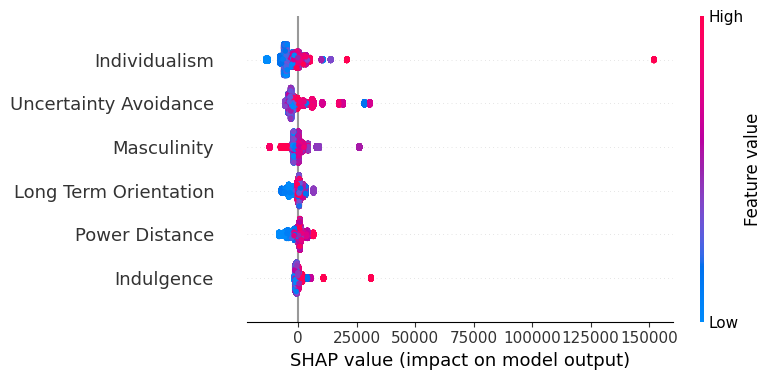

In [ ]:
import shap

                                                                                                                                    # Explainer for tree models
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_fixed)

                                                                                                                                       # Feature importance (global)
shap.summary_plot(shap_values, X_fixed, feature_names=fixed_features)


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


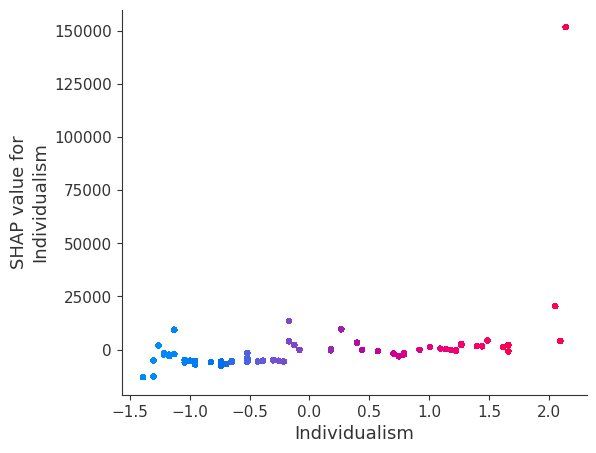

In [ ]:
shap.dependence_plot("Individualism", shap_values, X_fixed, feature_names=fixed_features)


In [ ]:
"""
import statsmodels.api as sm

                                                                                                                                          # Reuse your dataset
X_fixed = df[fixed_features]
y = df['daily Deaths']

                                                                                                                                             # Add constant for intercept
X_fixed_const = sm.add_constant(X_fixed)

                                                                                                                                            # Fit OLS regression
ols_model = sm.OLS(y, X_fixed_const).fit()

print(ols_model.summary())
"""

"\nimport statsmodels.api as sm\n\n                                                                                                                                          # Reuse your dataset\nX_fixed = df[fixed_features]\ny = df['daily Deaths']\n\n                                                                                                                                             # Add constant for intercept\nX_fixed_const = sm.add_constant(X_fixed)\n\n                                                                                                                                            # Fit OLS regression\nols_model = sm.OLS(y, X_fixed_const).fit()\n\nprint(ols_model.summary())\n"

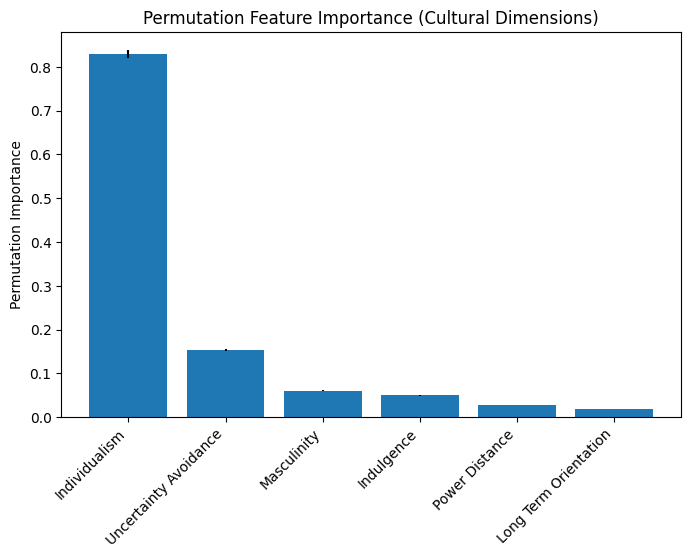

In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

                                                                                                                             # Prepare fixed features + target
X_fixed = df[fixed_features].values
y = df['daily Deaths'].values

                                                                                                                            # Fit the model again if not already fitted
from xgboost import XGBRegressor
model = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=4, random_state=42)
model.fit(X_fixed, y)

                                                                                                                               # Permutation importance
result = permutation_importance(model, X_fixed, y, n_repeats=10, random_state=42, n_jobs=-1)

                                                                                                                               # Extract importance scores
importances = result.importances_mean
stds = result.importances_std

                                                                                                                                 # Plot
sorted_idx = importances.argsort()[::-1]
plt.figure(figsize=(8, 5))
plt.bar(range(len(fixed_features)), importances[sorted_idx], yerr=stds[sorted_idx], align="center")
plt.xticks(range(len(fixed_features)), [fixed_features[i] for i in sorted_idx], rotation=45, ha="right")
plt.ylabel("Permutation Importance")
plt.title("Permutation Feature Importance (Cultural Dimensions)")
plt.show()


In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score
import numpy as np

X = df[fixed_features].values
y = df['daily Deaths'].values

                                                                                                                              # baseline score (R2)
baseline = model.score(X, y)                                                                                                      # or r2_score(y, model.predict(X))
print("Baseline R2:", baseline)

res = permutation_importance(model, X, y, n_repeats=20, random_state=42, n_jobs=-1, scoring=None)
                                                                                                                         # res.importances_mean is baseline_score - permuted_score (if scoring=None it uses estimator.score)

for feat, imp_mean, imp_std in zip(fixed_features, res.importances_mean, res.importances_std):
    pct_drop = 100 * (imp_mean / baseline) if baseline != 0 else np.nan
    print(f"{feat}: mean_drop={imp_mean:.4f}, std={imp_std:.4f}, pct_of_baseline={pct_drop:.1f}%")


Baseline R2: 0.7104115947756183
Individualism: mean_drop=0.8232, std=0.0090, pct_of_baseline=115.9%
Masculinity: mean_drop=0.0642, std=0.0017, pct_of_baseline=9.0%
Power Distance: mean_drop=0.0282, std=0.0006, pct_of_baseline=4.0%
Indulgence: mean_drop=0.0506, std=0.0014, pct_of_baseline=7.1%
Uncertainty Avoidance: mean_drop=0.1585, std=0.0021, pct_of_baseline=22.3%
Long Term Orientation: mean_drop=0.0185, std=0.0007, pct_of_baseline=2.6%


In [ ]:
from sklearn.inspection import permutation_importance
res_mse = permutation_importance(model, X, y, n_repeats=20, random_state=42,
                                scoring='neg_mean_squared_error', n_jobs=-1)
# note: result will be negative values (because scoring is neg_MSE); you can convert to MSE difference


In [ ]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# correlation matrix
print(df[fixed_features].corr())

# VIF
X_df = df[fixed_features].dropna()
vif_data = pd.DataFrame()
vif_data["feature"] = X_df.columns
vif_data["VIF"] = [variance_inflation_factor(X_df.values, i) for i in range(X_df.shape[1])]
print(vif_data)


                       Individualism  Masculinity  Power Distance  Indulgence  \
Individualism               1.000000     0.098017       -0.690813    0.138516   
Masculinity                 0.098017     1.000000        0.063480    0.075722   
Power Distance             -0.690813     0.063480        1.000000   -0.288169   
Indulgence                  0.138516     0.075722       -0.288169    1.000000   
Uncertainty Avoidance      -0.257377    -0.019593        0.293317   -0.206870   
Long Term Orientation       0.247614    -0.058818       -0.065404   -0.457481   

                       Uncertainty Avoidance  Long Term Orientation  
Individualism                      -0.257377               0.247614  
Masculinity                        -0.019593              -0.058818  
Power Distance                      0.293317              -0.065404  
Indulgence                         -0.206870              -0.457481  
Uncertainty Avoidance               1.000000               0.150604  
Long Term Or

In [1]:
# If your fixed features list is in fixed_features:
X_fixed_df = pd.DataFrame(X_fixed, columns=fixed_features)

# Now compute SHAP summary properly
shap_importance = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": fixed_features,
    "MeanAbsSHAP": shap_importance
}).sort_values(by="MeanAbsSHAP", ascending=False)

print("=== Mean absolute SHAP values ===")
print(shap_importance_df)


NameError: name 'pd' is not defined

In [ ]:
from sklearn.inspection import permutation_importance

res = permutation_importance(model, X_fixed_df, y, n_repeats=20,
                             random_state=42, n_jobs=-1, scoring=None)

pfi_df = pd.DataFrame({
    "Feature": fixed_features,
    "PFI_mean": res.importances_mean,
    "PFI_std": res.importances_std
}).sort_values(by="PFI_mean", ascending=False)

print("=== Permutation Feature Importance ===")
print(pfi_df)


=== Permutation Feature Importance ===
                 Feature  PFI_mean   PFI_std
0          Individualism  0.823194  0.009002
4  Uncertainty Avoidance  0.158470  0.002063
1            Masculinity  0.064223  0.001670
3             Indulgence  0.050602  0.001396
2         Power Distance  0.028163  0.000586
5  Long Term Orientation  0.018535  0.000660


In [ ]:
"""
from sklearn.inspection import permutation_importance

# baseline R²
baseline_score = model.score(X, y)
print("Baseline R²:", baseline_score)

res = permutation_importance(model, X, y, n_repeats=20,
                             random_state=42, n_jobs=-1, scoring=None)

pfi_df = pd.DataFrame({
    "Feature": X.columns,
    "PFI_mean": res.importances_mean,
    "PFI_std": res.importances_std,
    "Pct_of_baseline": 100 * res.importances_mean / baseline_score
}).sort_values(by="PFI_mean", ascending=False)

print("=== Permutation Feature Importance ===")
print(pfi_df)
"""

NameError: name 'model' is not defined

In [ ]:
"""
import os
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------
# 1) Load + preprocess
# -----------------------
path = "/content/drive/MyDrive/Merged_1.csv"
df = pd.read_csv(path)

# keep consistent column names
df = df.drop(['country_region', 'date.1'], axis=1, errors='ignore')
df = df.rename(columns={
    'location.1': 'Country',
    'total_deaths': 'TotalDeaths',
    'date': 'Date',
    'individualism': 'Individualism',
    'masculinity': 'Masculinity',
    'powerdistance': 'Power Distance',
    'uncertaintyavoidance': 'Uncertainty Avoidance',
    'longtermorientation': 'Long Term Orientation',
    'democracyindex2021': 'Democracy Index',
    'indulgence': 'Indulgence',
    'gdp_per_capita': 'GDP (per capita)',
    'aged_65_older': 'Aged 65 Older',
    'stringency_index': 'Stringency Index',
    'population': 'Population'
})

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df = df.sort_values(['Country', 'Date']).reset_index(drop=True)
df['time_step'] = df.groupby('Country').cumcount()

# fixed features only (culture, GDP, etc.)
fixed_features = [
    'Individualism','Masculinity','Power Distance','Indulgence',
    'Uncertainty Avoidance','Long Term Orientation'
]    #,'Population',
    #'GDP (per capita)','Aged 65 Older','Democracy Index'

# scale fixed features globally
df[fixed_features] = StandardScaler().fit_transform(df[fixed_features])

# ---- target: normalized cumulative deaths ----
df['TotalDeaths'] = df['TotalDeaths'].fillna(0)
daily = df.groupby('Country')['TotalDeaths'].diff().fillna(0).clip(lower=0)
df['CumulativeDeaths'] = daily.groupby(df['Country']).cumsum()
df['cumulative_norm'] = df.groupby('Country')['CumulativeDeaths'].transform(
    lambda x: x / (x.max() if x.max() > 0 else 1.0)
)

# -----------------------
# 2) Dataset
# -----------------------
class CountryFixedDataset(Dataset):

    Each country: predicts cumulative deaths sequence using only fixed features

    def __init__(self, df, enc_len=100):
        self.enc_len = enc_len
        self.groups = []
        for country, g in df.groupby('Country'):
            g = g.sort_values('time_step').reset_index(drop=True)
            if len(g) >= enc_len:
                self.groups.append((country, g))
        self.fixed_cols = fixed_features
        self.target_col = 'cumulative_norm'

    def __len__(self):
        return len(self.groups)

    def __getitem__(self, idx):
        country, g = self.groups[idx]
        x_fixed = g[self.fixed_cols].iloc[0].values.astype(np.float32)
        y = g[self.target_col].iloc[:self.enc_len].values.astype(np.float32)
        return torch.tensor(x_fixed), torch.tensor(y), country

# -----------------------
# 3) Model (Fixed-only MLP)
# -----------------------
class FixedMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, seq_len):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, seq_len)

    def forward(self, x_fixed):
        h = F.relu(self.fc1(x_fixed))
        h = F.relu(self.fc2(h))
        y = self.out(h)
        return torch.sigmoid(y)   # [B, seq_len], normalized deaths ∈ [0,1]

# -----------------------
# 4) Train
# -----------------------
def train_model(model, loader, epochs=2000, lr=1e-3, clip=1.0, verbose_every=100):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    best = float('inf'); best_state = copy.deepcopy(model.state_dict())

    for ep in range(1, epochs+1):
        model.train()
        total = 0.0
        for x_fixed, y, _ in loader:
            opt.zero_grad()
            pred = model(x_fixed)
            loss = loss_fn(pred, y)
            loss.backward()
            if clip:
                nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()
            total += loss.item() * x_fixed.size(0)
        epoch_loss = total / len(loader.dataset)
        if epoch_loss < best:
            best = epoch_loss
            best_state = copy.deepcopy(model.state_dict())
        if ep % verbose_every == 0 or ep == 1 or ep == epochs:
            print(f"Epoch {ep} — Loss: {epoch_loss:.6f} (best {best:.6f})")

    model.load_state_dict(best_state)
    print(f"\nBest training loss: {best:.6f}")
    return model

# -----------------------,'Population',
    'GDP (per capita)','Aged 65 Older','Democracy Index'
# 5) Run training
# -----------------------
ENC_LEN = 100
BATCH_SIZE = 78
EPOCHS = 2000
LR = 1e-2

dataset = CountryFixedDataset(df, enc_len=ENC_LEN)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

model = FixedMLP(
    input_dim=len(fixed_features),
    hidden_dim=128,
    seq_len=ENC_LEN
)

model = train_model(model, loader, epochs=EPOCHS, lr=LR, clip=1.0, verbose_every=100)

# -----------------------
# 6) Evaluate one country
# -----------------------
country_name = "Bulgaria"  # <-- change here
g = df[df['Country']==country_name].sort_values('time_step').reset_index(drop=True)
x_fixed = torch.tensor(g[fixed_features].iloc[0].values.astype(np.float32)).unsqueeze(0)         #unslabel='Train/Forecast split'queeze(0)
true_seq = g['cumulative_norm'].iloc[:ENC_LEN].values

with torch.no_grad():
    pred_seq = model(x_fixed).squeeze(0).cpu().numpy()

# plot
plt.figure(figsize=(12,4.8))
plt.plot(true_seq, 'o-', label="True Cumulative", color='C0')
plt.plot(pred_seq, 'x--', label="Predicted Cumulative", color='red')
plt.title(f"Fixed-only model prediction — {country_name}")
plt.xlabel("Day")
plt.ylabel("Normalized cumulative deaths")
plt.legend(); plt.grid(True); plt.show()

# metrics
mse = mean_squared_error(true_seq, pred_seq)
r2 = r2_score(true_seq, pred_seq)
print(f"{country_name} — MSE: {mse:.4f}, R²: {r2:.4f}")

"""

'\nimport os\nimport copy\nimport numpy as np\nimport pandas as pd\nimport torch\nimport torch.nn as nn\nimport torch.nn.functional as F\nfrom torch.utils.data import Dataset, DataLoader\nfrom sklearn.preprocessing import StandardScaler\nimport matplotlib.pyplot as plt\nfrom sklearn.metrics import mean_squared_error, r2_score\n\n# -----------------------\n# 1) Load + preprocess\n# -----------------------\npath = "/content/drive/MyDrive/Merged_1.csv"\ndf = pd.read_csv(path)\n\n# keep consistent column names\ndf = df.drop([\'country_region\', \'date.1\'], axis=1, errors=\'ignore\')\ndf = df.rename(columns={\n    \'location.1\': \'Country\',\n    \'total_deaths\': \'TotalDeaths\',\n    \'date\': \'Date\',\n    \'individualism\': \'Individualism\',\n    \'masculinity\': \'Masculinity\',\n    \'powerdistance\': \'Power Distance\',\n    \'uncertaintyavoidance\': \'Uncertainty Avoidance\',\n    \'longtermorientation\': \'Long Term Orientation\',\n    \'democracyindex2021\': \'Democracy Index\

In [ ]:
"""
import shap
import numpy as np

# Use a small background dataset
background = X_fixed[:100]

# DeepExplainer works with TF/Keras models
explainer = shap.DeepExplainer(model, background)

# Compute SHAP values for a subset
shap_values = explainer.shap_values(X_fixed[:500])

# Mean absolute SHAP per feature
shap_importance = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": fixed_features,
    "MeanAbsSHAP": shap_importance
}).sort_values(by="MeanAbsSHAP", ascending=False)

print("=== SHAP values for MLP (Keras) ===")
print(shap_importance_df)
"""

'\nimport shap\nimport numpy as np\n\n# Use a small background dataset\nbackground = X_fixed[:100]\n\n# DeepExplainer works with TF/Keras models\nexplainer = shap.DeepExplainer(model, background)\n\n# Compute SHAP values for a subset\nshap_values = explainer.shap_values(X_fixed[:500])\n\n# Mean absolute SHAP per feature\nshap_importance = np.abs(shap_values).mean(axis=0)\n\nshap_importance_df = pd.DataFrame({\n    "Feature": fixed_features,\n    "MeanAbsSHAP": shap_importance\n}).sort_values(by="MeanAbsSHAP", ascending=False)\n\nprint("=== SHAP values for MLP (Keras) ===")\nprint(shap_importance_df)\n'

In [ ]:
"""
import shap
import torch
import numpy as np

# Put model in evaluation mode
model.eval()

# Wrap model in a prediction function
def predict_fn(x):
    x_tensor = torch.tensor(x, dtype=torch.float32)
    with torch.no_grad():
        return model(x_tensor).numpy()

# Use a small sample of data as background (SHAP baseline)
background = X_fixed[:100]   # take first 100 rows as reference
explainer = shap.KernelExplainer(predict_fn, background)

# Explain a subset of samples (say 500 for speed)
shap_values = explainer.shap_values(X_fixed[:500], nsamples=100)

# Convert to numpy array (samples × features)
shap_values = np.array(shap_values)

# Mean absolute SHAP per feature
shap_importance = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": fixed_features,
    "MeanAbsSHAP": shap_importance
}).sort_values(by="MeanAbsSHAP", ascending=False)

print("=== SHAP values for MLP ===")
print(shap_importance_df)
"""

'\nimport shap\nimport torch\nimport numpy as np\n\n# Put model in evaluation mode\nmodel.eval()\n\n# Wrap model in a prediction function\ndef predict_fn(x):\n    x_tensor = torch.tensor(x, dtype=torch.float32)\n    with torch.no_grad():\n        return model(x_tensor).numpy()\n\n# Use a small sample of data as background (SHAP baseline)\nbackground = X_fixed[:100]   # take first 100 rows as reference\nexplainer = shap.KernelExplainer(predict_fn, background)\n\n# Explain a subset of samples (say 500 for speed)\nshap_values = explainer.shap_values(X_fixed[:500], nsamples=100)\n\n# Convert to numpy array (samples × features)\nshap_values = np.array(shap_values)\n\n# Mean absolute SHAP per feature\nshap_importance = np.abs(shap_values).mean(axis=0)\n\nshap_importance_df = pd.DataFrame({\n    "Feature": fixed_features,\n    "MeanAbsSHAP": shap_importance\n}).sort_values(by="MeanAbsSHAP", ascending=False)\n\nprint("=== SHAP values for MLP ===")\nprint(shap_importance_df)\n'

In [ ]:
df.columns

Index(['Country', 'TotalDeaths', 'Date', 'Individualism', 'Masculinity',
       'Power Distance', 'Indulgence', 'Uncertainty Avoidance',
       'Long Term Orientation', 'Democracy Index', 'GDP (per capita)',
       'Aged 65 Older', 'Stringency Index', 'Population',
       'retail_and_recreation_percent_change_from_baseline',
       'grocery_and_pharmacy_percent_change_from_baseline',
       'parks_percent_change_from_baseline',
       'transit_stations_percent_change_from_baseline',
       'workplaces_percent_change_from_baseline',
       'residential_percent_change_from_baseline', 'time_step',
       'CumulativeDeaths', 'cumulative_norm'],
      dtype='object')

In [ ]:
"""
import pandas as pd
import numpy as np
import shap

# Define fixed features
fixed_features = [
    'Individualism', 'Masculinity', 'Power Distance',
    'Indulgence', 'Uncertainty Avoidance',
    'Long Term Orientation', 'Population'
]

# Extract X and y
X_fixed = df[fixed_features].values
y = df['daily Deaths'].values

# Keep feature names
X_fixed_df = pd.DataFrame(X_fixed, columns=fixed_features)
"""

"\nimport pandas as pd\nimport numpy as np\nimport shap\n\n# Define fixed features\nfixed_features = [\n    'Individualism', 'Masculinity', 'Power Distance',\n    'Indulgence', 'Uncertainty Avoidance',\n    'Long Term Orientation', 'Population'\n]\n\n# Extract X and y\nX_fixed = df[fixed_features].values\ny = df['daily Deaths'].values\n\n# Keep feature names\nX_fixed_df = pd.DataFrame(X_fixed, columns=fixed_features)\n"

In [ ]:
"""
model.eval()   # put into eval mode

def predDevansh Asthana, Cultural Secretary, 8700197716

cultural.committee@snu.edu.inict_fn(x):
    x_tensor = torch.tensor(x, dtype=torch.float32)
    with torch.no_grad():
        return model(x_tensor).numpy()

background = X_fixed[:100]
explainer = shap.KernelExplainer(predict_fn, background)
shap_values = explainer.shap_values(X_fixed[:500], nsamples=100)
"""

'\nmodel.eval()   # put into eval mode\n\ndef predict_fn(x):\n    x_tensor = torch.tensor(x, dtype=torch.float32)\n    with torch.no_grad():\n        return model(x_tensor).numpy()\n\nbackground = X_fixed[:100]\nexplainer = shap.KernelExplainer(predict_fn, background)\nshap_values = explainer.shap_values(X_fixed[:500], nsamples=100)\n'

In [ ]:
"""
import torch

# Assume your trained PyTorch model is called `model`
model.eval()

# Wrap model in prediction function for SHAP
def predict_fn(x):
    x_tensor = torch.tensor(x, dtype=torch.float32)
    with torch.no_grad():
        return model(x_tensor).numpy()

# Background sample (for baseline expectations)
background = X_fixed[:100]

# KernelExplainer (slow → use subset for demo)
explainer = shap.KernelExplainer(predict_fn, background)

# Explain a subset (say first 500 samples)
shap_values = explainer.shap_values(X_fixed[:500], nsamples=100)

# Convert to array
shap_values = np.array(shap_values)

# Mean absolute SHAP values per feature
shap_importance = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": fixed_features,
    "MeanAbsSHAP": shap_importance
}).sort_values(by="MeanAbsSHAP", ascending=False)

print("=== SHAP values for MLP (PyTorch) ===")
print(shap_importance_df)
"""


'\nimport torch\n\n# Assume your trained PyTorch model is called `model`\nmodel.eval()\n\n# Wrap model in prediction function for SHAP\ndef predict_fn(x):\n    x_tensor = torch.tensor(x, dtype=torch.float32)\n    with torch.no_grad():\n        return model(x_tensor).numpy()\n\n# Background sample (for baseline expectations)\nbackground = X_fixed[:100]\n\n# KernelExplainer (slow → use subset for demo)\nexplainer = shap.KernelExplainer(predict_fn, background)\n\n# Explain a subset (say first 500 samples)\nshap_values = explainer.shap_values(X_fixed[:500], nsamples=100)\n\n# Convert to array\nshap_values = np.array(shap_values)\n\n# Mean absolute SHAP values per feature\nshap_importance = np.abs(shap_values).mean(axis=0)\n\nshap_importance_df = pd.DataFrame({\n    "Feature": fixed_features,\n    "MeanAbsSHAP": shap_importance\n}).sort_values(by="MeanAbsSHAP", ascending=False)\n\nprint("=== SHAP values for MLP (PyTorch) ===")\nprint(shap_importance_df)\n'